# Manifold Alignment - Results Notebook 

In [4]:
# Import all functions: 

# Seed for reproducibility
seed = 42

# External Imports: 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.cm as cm
import plotly.graph_objects as go
from scipy.stats import ortho_group


# Own functions 
from Main_functions import *
from Datasets_Plotting import * # plot_3d() and plot_2d() (+Embedding versions)
#from Evalutation_functions import * # Evaluation functions


### Code for a single alignment process: 

------
# Alignment Experiments

Roman T - Direct Alignment: 
(Coloured for three distinct sections)

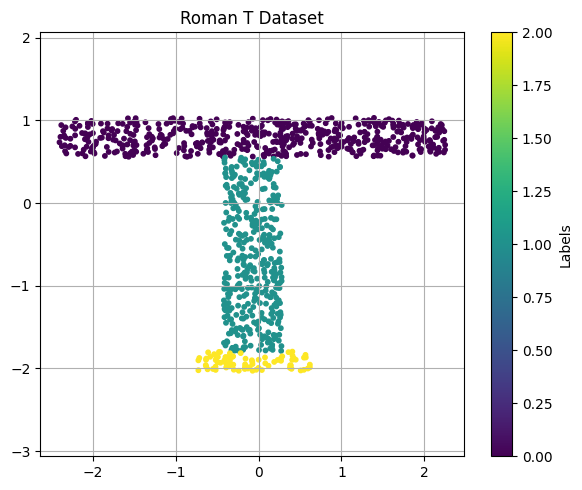

In [6]:
# Generate data: 
X, labels = generate_roman_T(total_points=1000, noise_std=0)

# Scaling: 
scaler_X = StandardScaler()
X_orig = scaler_X.fit_transform(X)

# Plotting: 
plot_2d(X_orig, labels, title="Roman T Dataset")

In [ ]:
# Selfalignment - Single execution:
Y = X 
X = X 

# Examples for rotational dependency of random projection: 
f_net, g_net, loss = train_joint_embedding(X, Y, epochs=2000, verbose=True, k=15, embed_dim=2, alpha=0.1)

# Calculate distance between corresponding points in the embedding space
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

# Compute the embedded representations
fX = f_net(X_tensor)
gY = g_net(Y_tensor)

# Compute sum of mean-Euclidean-distances between corresponding embedded points
disagreement = torch.norm(fX - gY, dim=1).mean().item()


# f_net, g_net, loss = proceed_train_joint_embedding(X, Y, f_net, g_net, epochs=1000, lr=1e-3, k=20, embed_dim=2, device='cpu', verbose=True, alpha=0.5)


plot_embeddings_2d(X, Y, 
                   labels_X=labels, 
                   labels_Y=labels,
                   f_net=f_net, 
                   g_net=g_net)
disagreement


In [ ]:
# Selfalignment: 
X = X_orig
Y = X

# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 50
best_loss = np.inf
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=3000, verbose=False, k=20, embed_dim=2, alpha=0.3)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=2000, lr=1e-3, k=20, embed_dim=2, device='cpu', verbose=True, alpha=0.5)


0
1
2


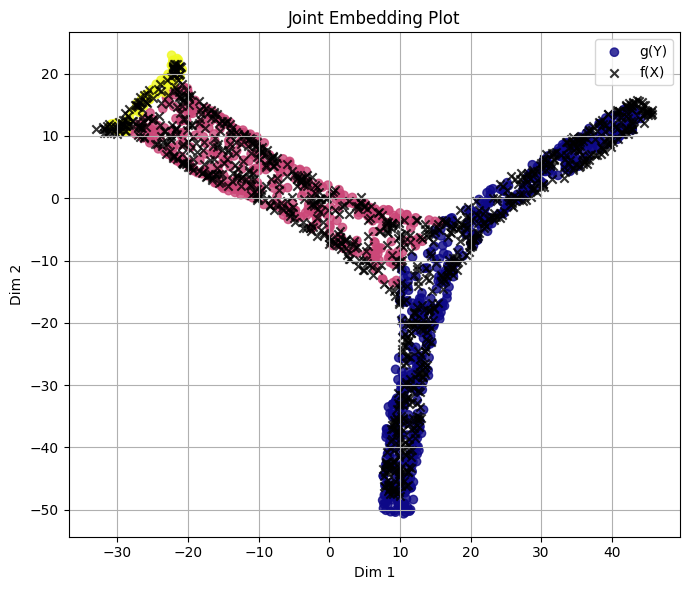

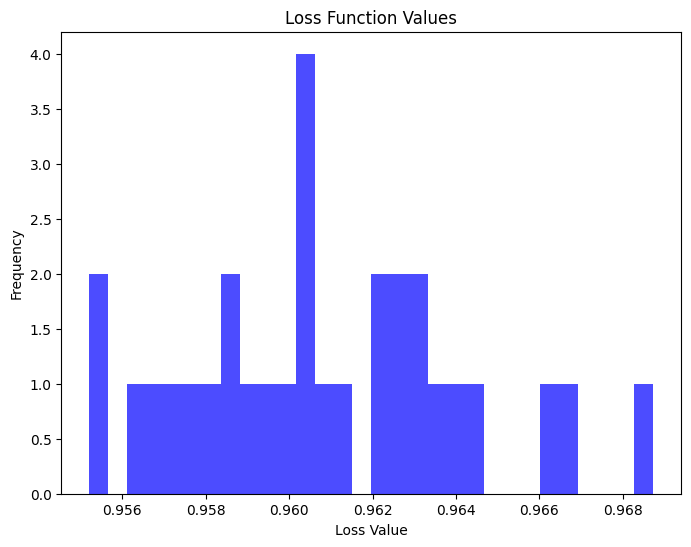

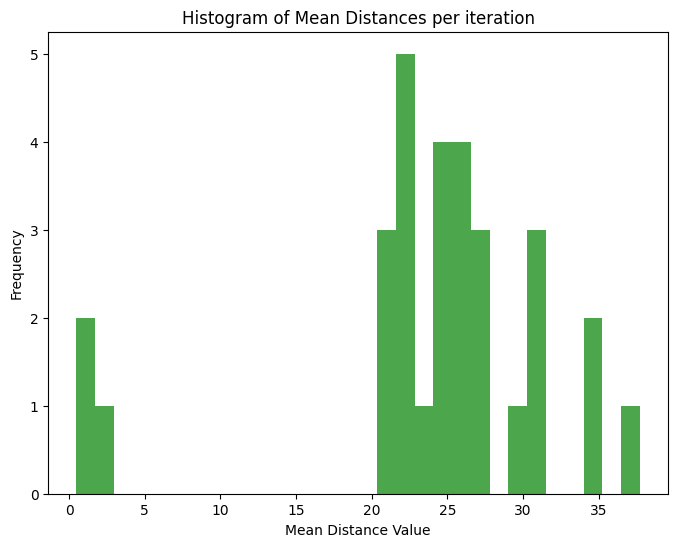

In [ ]:
plot_embeddings_2d(X, Y, 
                   labels_X=labels, 
                   labels_Y=labels,
                   f_net=bf_net, 
                   g_net=bg_net)


# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

# Robustness-tests 
### High dimensional isometric projection alignment 

In [ ]:
# Project data in two distinct high dimensioal spaces (first isometrically): 
X = project_to_high_dim(X_orig, target_dim=150, mode="isometric", seed=1)
Y = project_to_high_dim(X_orig, target_dim=300, mode="isometric", seed=1)


In [ ]:
# Execute alignment loop: 

# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 50
best_loss = np.inf

# Adapt alpha for better performance! 
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=2500, verbose=False, k=15, embed_dim=2, alpha=0.05)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=1000, lr=1e-3, k=20, embed_dim=2, device='cpu', verbose=True, alpha=0.05)


0
Epoch 100, Loss: 0.9497, KL: 0.9449, MMD: 0.0048
Epoch 200, Loss: 0.9470, KL: 0.9422, MMD: 0.0048
Epoch 300, Loss: 0.9447, KL: 0.9400, MMD: 0.0048
Epoch 400, Loss: 0.9428, KL: 0.9380, MMD: 0.0048
Epoch 500, Loss: 0.9414, KL: 0.9367, MMD: 0.0047
Epoch 600, Loss: 0.9399, KL: 0.9353, MMD: 0.0047
Epoch 700, Loss: 0.9386, KL: 0.9339, MMD: 0.0046
Epoch 800, Loss: 0.9372, KL: 0.9325, MMD: 0.0046
Epoch 900, Loss: 0.9359, KL: 0.9313, MMD: 0.0046
Epoch 1000, Loss: 0.9349, KL: 0.9303, MMD: 0.0046


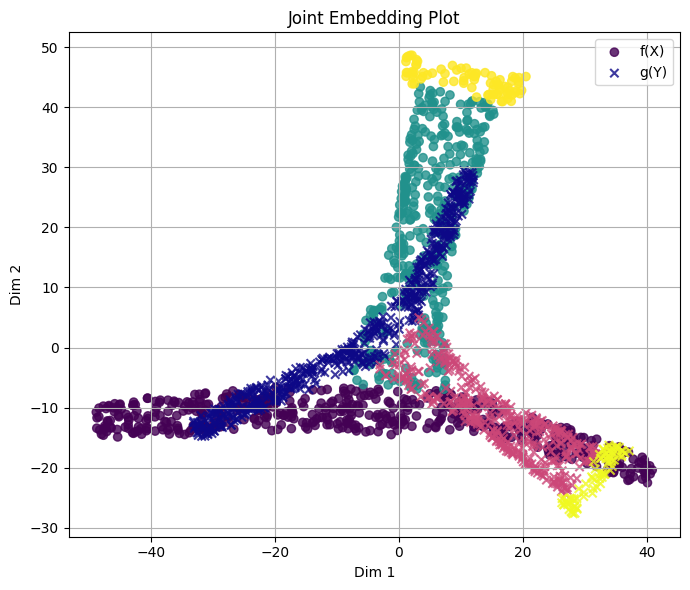

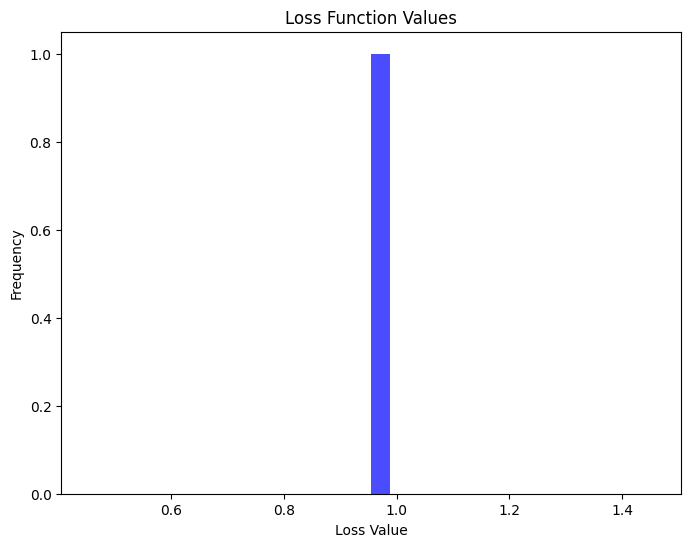

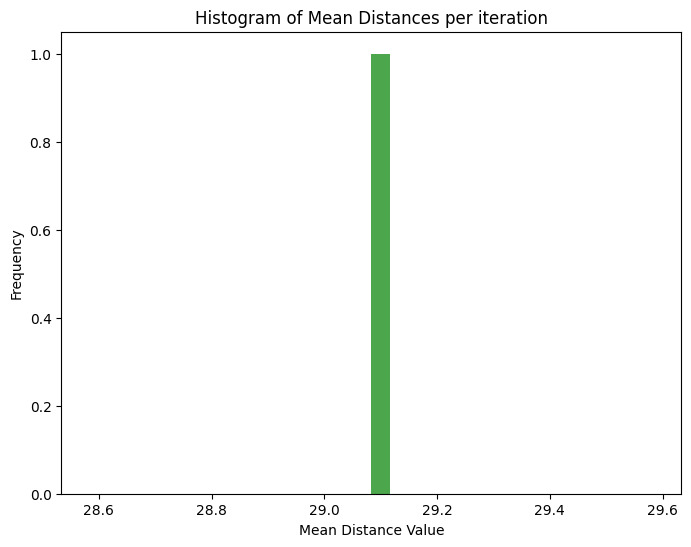

In [68]:
plot_embeddings_2d(X, Y, 
                   labels_X=labels, 
                   labels_Y=labels,
                   f_net=bf_net, 
                   g_net=bg_net)


# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

In [110]:
# Non-Isometric alignment: 

# Project data in two distinct high dimensioal spaces (now randomly): 
X = project_to_high_dim(X_orig, target_dim=400, mode="random", seed=None)
Y = project_to_high_dim(X_orig, target_dim=600, mode="random", seed=None)

# Do Pca to see the effect of the distortion: 
pca = PCA(n_components=3)
pca_X = pca.fit_transform(X)
pca_Y = pca.fit_transform(Y)
plot_3d(pca_X, labels= labels)
#plot_3d(pca_Y, labels= labels)


In [111]:
# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 25
best_loss = np.inf
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=3000, verbose=False, k=20, embed_dim=2, alpha=0.05)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=1000, lr=1e-3, k=20, embed_dim=2, device='cpu', verbose=True, alpha=0.05)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
Epoch 100, Loss: 0.0952, KL: 0.0952, MMD: 0.0000
Epoch 200, Loss: 0.0952, KL: 0.0951, MMD: 0.0000
Epoch 300, Loss: 0.0951, KL: 0.0951, MMD: 0.0001
Epoch 400, Loss: 0.0951, KL: 0.0950, MMD: 0.0001
Epoch 500, Loss: 0.0950, KL: 0.0949, MMD: 0.0001
Epoch 600, Loss: 0.0950, KL: 0.0949, MMD: 0.0001
Epoch 700, Loss: 0.0949, KL: 0.0948, MMD: 0.0001
Epoch 800, Loss: 0.0948, KL: 0.0948, MMD: 0.0001
Epoch 900, Loss: 0.0948, KL: 0.0948, MMD: 0.0001
Epoch 1000, Loss: 0.0948, KL: 0.0947, MMD: 0.0001


In [132]:
# Investigate loss and disagreement 
fX = bf_net(X_tensor)
gY = bg_net(Y_tensor)
disagreement = torch.norm(fX - gY, dim=1).mean().item()
disagreement

0.15411818027496338

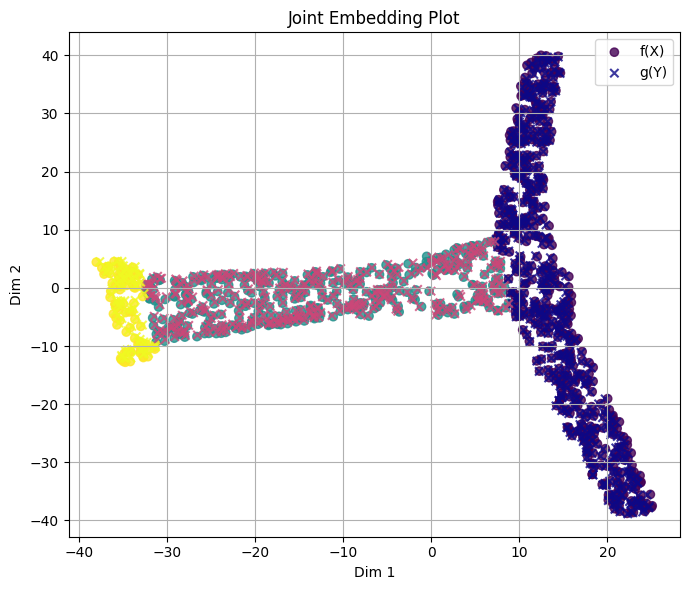

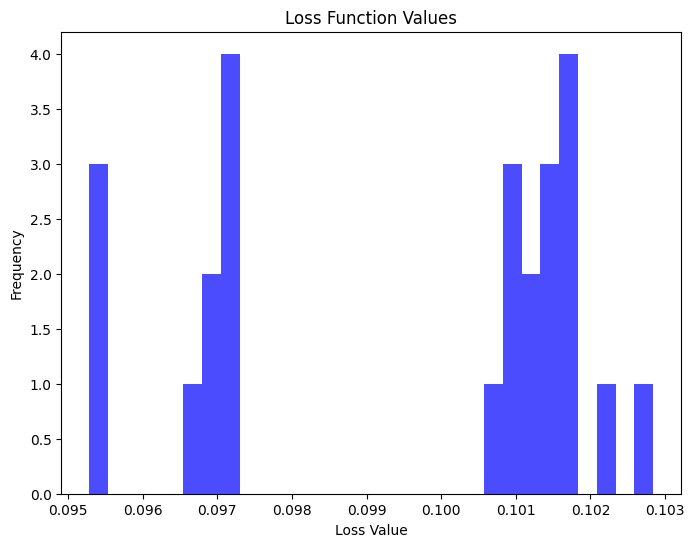

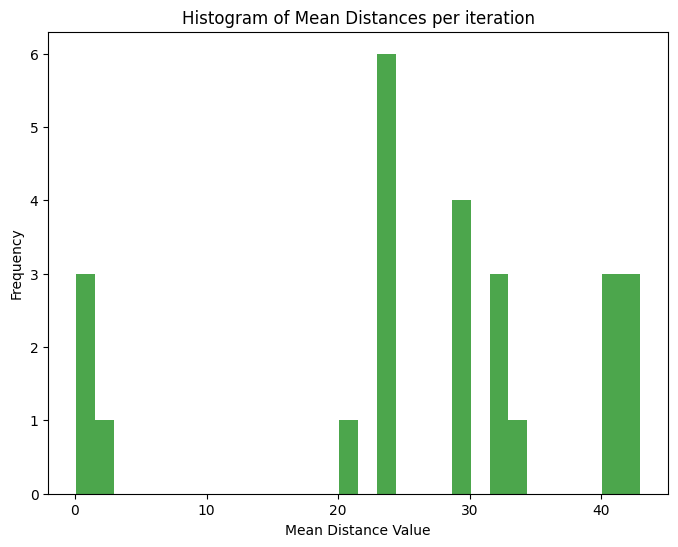

In [113]:
plot_embeddings_2d(X, Y, 
                   labels_X=labels, 
                   labels_Y=labels,
                   f_net=bf_net, 
                   g_net=bg_net)


# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

### Noisy alignment (Manifold noise + Outlier noise)

In [ ]:
# Still in progress

---
# Swiss role 

In [ ]:
from sklearn.datasets import make_swiss_roll # Function for swiss roll

X, labels = make_swiss_roll(n_samples=1000)

scaler_X = StandardScaler()
X_orig = scaler_X.fit_transform(X)



In [ ]:
# Selfalignment: 
X = X_orig
Y = X

# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 1
best_loss = np.inf
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=2000, verbose=False, k=20, embed_dim=3, alpha=0.5)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=2000, lr=1e-3, k=20, embed_dim=3, device='cpu', verbose=True, alpha=0.5)


0
Epoch 100, Loss: 1.2159, KL: 1.2102, MMD: 0.0058
Epoch 200, Loss: 1.1993, KL: 1.1931, MMD: 0.0061
Epoch 300, Loss: 1.1830, KL: 1.1764, MMD: 0.0066
Epoch 400, Loss: 1.1662, KL: 1.1593, MMD: 0.0070
Epoch 500, Loss: 1.1504, KL: 1.1432, MMD: 0.0072
Epoch 600, Loss: 1.1346, KL: 1.1271, MMD: 0.0074
Epoch 700, Loss: 1.1190, KL: 1.1114, MMD: 0.0076
Epoch 800, Loss: 1.1055, KL: 1.0979, MMD: 0.0077
Epoch 900, Loss: 1.0944, KL: 1.0866, MMD: 0.0077
Epoch 1000, Loss: 1.0843, KL: 1.0765, MMD: 0.0078
Epoch 1100, Loss: 1.0749, KL: 1.0670, MMD: 0.0079
Epoch 1200, Loss: 1.0661, KL: 1.0581, MMD: 0.0079
Epoch 1300, Loss: 1.0578, KL: 1.0499, MMD: 0.0079
Epoch 1400, Loss: 1.0518, KL: 1.0439, MMD: 0.0079
Epoch 1500, Loss: 1.0474, KL: 1.0396, MMD: 0.0078
Epoch 1600, Loss: 1.0435, KL: 1.0358, MMD: 0.0078
Epoch 1700, Loss: 1.0391, KL: 1.0313, MMD: 0.0078
Epoch 1800, Loss: 1.0352, KL: 1.0275, MMD: 0.0077
Epoch 1900, Loss: 1.0319, KL: 1.0242, MMD: 0.0077
Epoch 2000, Loss: 1.0288, KL: 1.0212, MMD: 0.0076


In [ ]:
fX = bf_net(X_tensor)
gY = bg_net(Y_tensor)
disagreement = torch.norm(fX - gY, dim=1).mean().item()
disagreement

0.3460584878921509

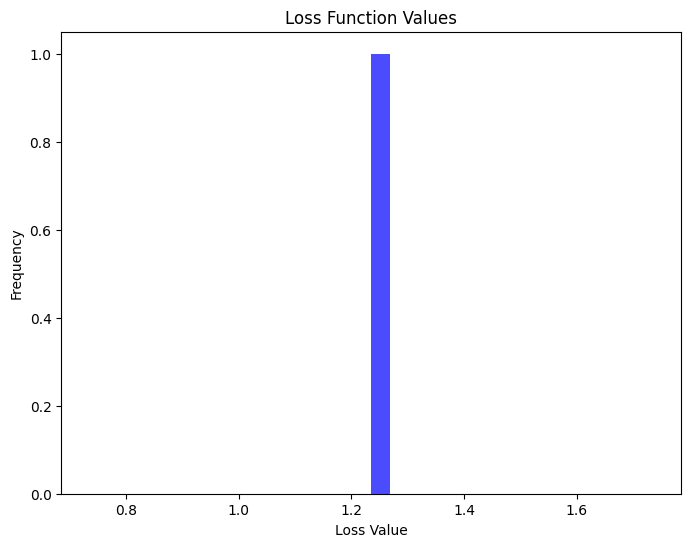

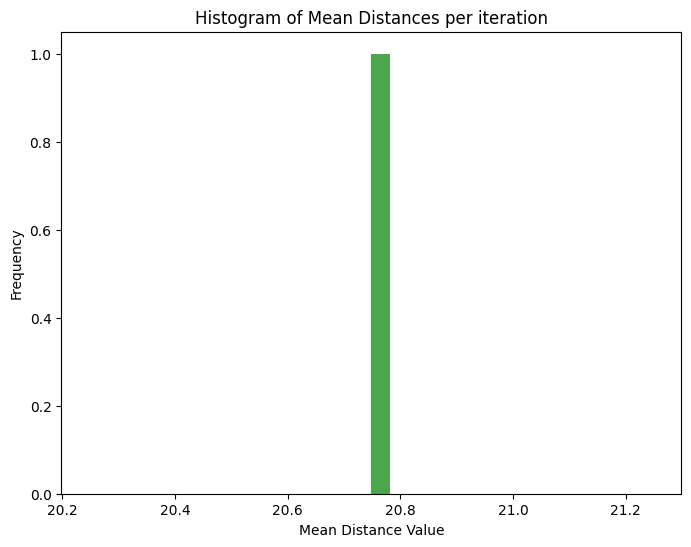

In [85]:
plot_joint_embeddings_3d(X, Y,
                         labels_X=labels,  
                            labels_Y=labels,
                            f_net=bf_net,
                            g_net=bg_net,
                            title="Swiss Roll Joint Embedding",
                            point_size=4)

# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

# Robustness tests - Swiss Roll 
### Non-Isometric transformation into high dimensional space: 

In [120]:
# Project data in two distinct high dimensioal spaces (now randomly): 
X = project_to_high_dim(X_orig, target_dim=450, mode="random", seed=1)
Y = project_to_high_dim(X_orig, target_dim=900, mode="random", seed=1)

# Do Pca to see the effect of the distortion: 
pca = PCA(n_components=3)
pca_X = pca.fit_transform(X)
pca_Y = pca.fit_transform(Y)


In [122]:
#plot_3d(pca_X, labels= labels)
plot_3d(pca_Y, labels= labels)

In [123]:
# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 75
best_loss = np.inf
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=3000, verbose=False, k=20, embed_dim=3, alpha=0.005)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=5000, lr=1e-3, k=20, embed_dim=3, device='cpu', verbose=True, alpha=0.005)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
Epoch 100, Loss: 0.0126, KL: 0.0126, MMD: 0.0000
Epoch 200, Loss: 0.0125, KL: 0.0125, MMD: 0.0000
Epoch 300, Loss: 0.0125, KL: 0.0125, MMD: 0.0000
Epoch 400, Loss: 0.0125, KL: 0.0125, MMD: 0.0000
Epoch 500, Loss: 0.0126, KL: 0.0125, MMD: 0.0001
Epoch 600, Loss: 0.0126, KL: 0.0125, MMD: 0.0002
Epoch 700, Loss: 0.0126, KL: 0.0124, MMD: 0.0001
Epoch 800, Loss: 0.0125, KL: 0.0124, MMD: 0.0001
Epoch 900, Loss: 0.0125, KL: 0.0124, MMD: 0.0000
Epoch 1000, Loss: 0.0124, KL: 0.0124, MMD: 0.0000
Epoch 1100, Loss: 0.0126, KL: 0.0123, MMD: 0.0003
Epoch 1200, Loss: 0.0123, KL: 0.0123, MMD: 0.0000
Epoch 1300, Loss: 0.0123, KL: 0.0122, MMD: 0.0000
Epoch 1400, Loss: 0.0123, KL: 0.0122, MMD: 0.0001
Epoch 1500, Loss: 0.0121, KL: 0.0121, MMD: 0.0000
Epoch 1600, Loss: 0.0121, KL: 0.0120, MMD: 0

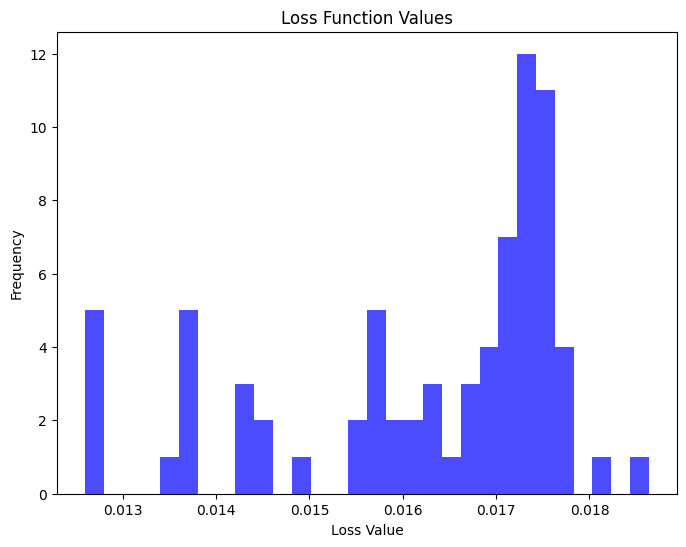

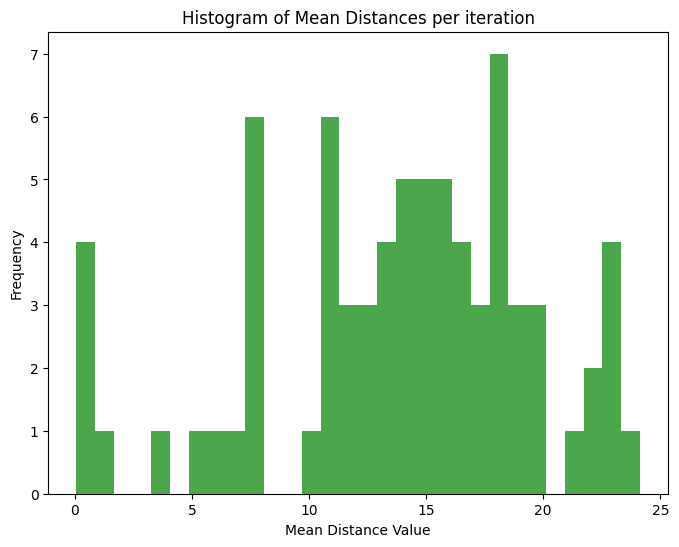

In [125]:
plot_joint_embeddings_3d(X, Y,
                         labels_X=labels,  
                            labels_Y=labels,
                            f_net=bf_net,
                            g_net=bg_net,
                            title="Swiss Roll Joint Embedding",
                            point_size=4)

# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

In [129]:
loss

tensor(0.0116, grad_fn=<AddBackward0>)

---
# Simple graph data 

In [133]:
# Example configuration for 3 clusters in 3D
hubs_config = [
    ([0, 0, 0], 200, 0.5),   # center at (0,0,0), 100 points, variance 0.2
    ([3, 0, 0], 100, 0.1),   
    ([1.5, 2.5, 0], 250, 0.3),
    ([5,1,1],75,0.4) 
]

X, labels = generate_clusters_with_bridges_data_v2(
    hubs_config=hubs_config,
    connect=1.0,        # connect all pairs
    noise=0.00,         # cluster noise
    noise_c=0.05)

scaler_Y = StandardScaler()
X_orig = scaler_X.fit_transform(X)

In [127]:
plot_3d(X_orig, labels, title="3D Clusters with Bridges", point_size=5)

In [ ]:
# Selfalignment: 
X = X_orig
Y = X


# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 50
best_loss = np.inf
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=3000, verbose=False, k=20, embed_dim=3, alpha=0.05)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=2000, lr=1e-3, k=20, embed_dim=3, device='cpu', verbose=True, alpha=0.1)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
Epoch 100, Loss: 0.2448, KL: 0.2446, MMD: 0.0002
Epoch 200, Loss: 0.2426, KL: 0.2424, MMD: 0.0002
Epoch 300, Loss: 0.2404, KL: 0.2403, MMD: 0.0002
Epoch 400, Loss: 0.2384, KL: 0.2382, MMD: 0.0002
Epoch 500, Loss: 0.2367, KL: 0.2365, MMD: 0.0002
Epoch 600, Loss: 0.2355, KL: 0.2353, MMD: 0.0002
Epoch 700, Loss: 0.2344, KL: 0.2343, MMD: 0.0002
Epoch 800, Loss: 0.2336, KL: 0.2335, MMD: 0.0002
Epoch 900, Loss: 0.2330, KL: 0.2328, MMD: 0.0002
Epoch 1000, Loss: 0.2325, KL: 0.2323, MMD: 0.0002
Epoch 1100, Loss: 0.2321, KL: 0.2319, MMD: 0.0002
Epoch 1200, Loss: 0.2317, KL: 0.2315, MMD: 0.0002
Epoch 1300, Loss: 0.2314, KL: 0.2312, MMD: 0.0002
Epoch 1400, Loss: 0.2311, KL: 0.2309, MMD: 0.0002
Epoch 1500, Loss: 0.2308, KL: 0.2306, MMD: 0.0002
Epoch 1600, Loss: 0.2305, KL: 0.2303, MMD: 0.0002
Epoch 1700, Loss: 0.2303, KL: 0.2301, MMD: 0.0002
Epoch 1800, Loss: 0

In [139]:
# Investigate loss and disagreement for best alignment:
fX = bf_net(X_tensor)
gY = bg_net(Y_tensor)
disagreement = torch.norm(fX - gY, dim=1).mean().item()
disagreement

0.26773616671562195

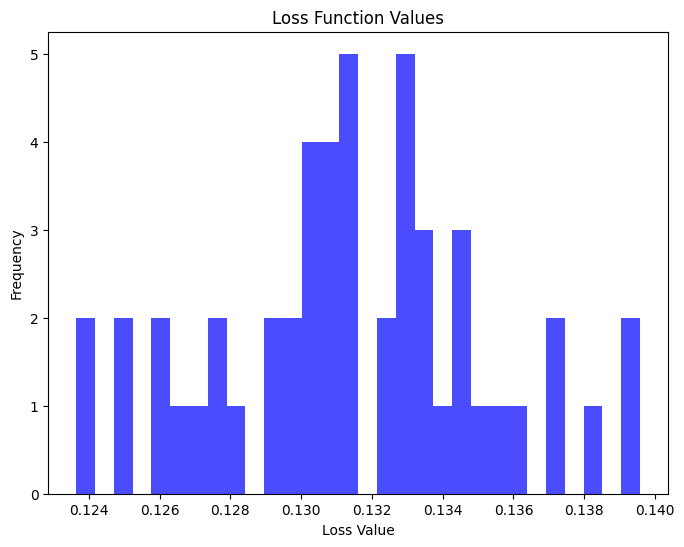

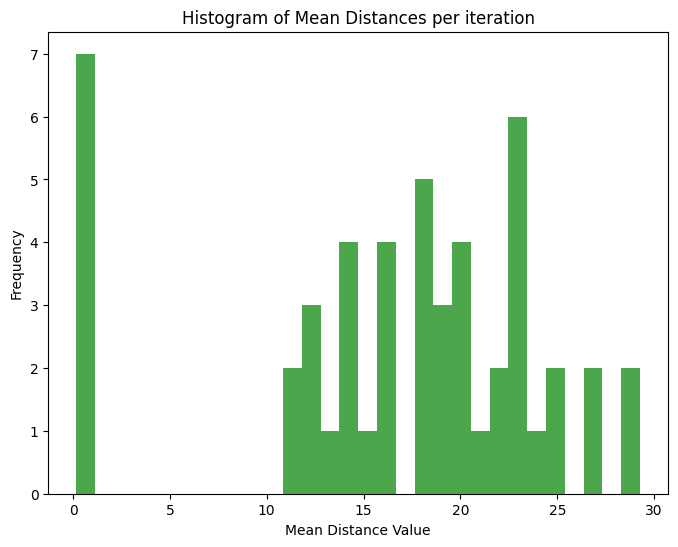

In [55]:
plot_joint_embeddings_3d(X, Y,
                         labels_X=labels,  
                            labels_Y=labels,
                            f_net=bf_net,
                            g_net=bg_net,
                            title="Simple Graph Joint Embedding",
                            point_size=4)

# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

### Noise and Projection into higher dim space experiments

In [134]:
# Noisy random projection: 
X = project_to_high_dim(X_orig, 600, mode='random', seed=None)
Y = project_to_high_dim(X_orig, 20, mode='random', seed=None)


# Do Pca to see the effect of the distortion: 
pca = PCA(n_components=3)
pca_X = pca.fit_transform(X)
pca_Y = pca.fit_transform(Y)
plot_3d(pca_X, labels= labels)
#plot_3d(pca_Y, labels= labels)

In [135]:
# Lists for losses and mean distances: 
loss_function_val = []
mean_distances_error = []

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)


nsims = 20
best_loss = np.inf
for i in range(nsims):
    print(i)
    f_net, g_net, loss = train_joint_embedding(X, Y, epochs=3000, verbose=False, k=20, embed_dim=3, alpha=0.01)

    # Construct list of losses: 
    # Calculate mean-distance disagreement between both embeddings 
    fX = f_net(X_tensor)
    gY = g_net(Y_tensor)
    disagreement = torch.norm(fX - gY, dim=1).mean().item()

    # Construct list of losses: 
    loss_function_val.append(loss.item())
    mean_distances_error.append(disagreement)
    
    if loss.item() < best_loss:
        bf_net, bg_net = f_net, g_net
        best_loss = loss.item()

# Finalize training on best embedding: 
bf_net, bg_net, loss = proceed_train_joint_embedding(X, Y, bf_net, bg_net, epochs=2000, lr=1e-3, k=20, embed_dim=3, device='cpu', verbose=True, alpha=0.01)



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
Epoch 100, Loss: 0.0290, KL: 0.0289, MMD: 0.0001
Epoch 200, Loss: 0.0290, KL: 0.0289, MMD: 0.0001
Epoch 300, Loss: 0.0289, KL: 0.0288, MMD: 0.0001
Epoch 400, Loss: 0.0289, KL: 0.0288, MMD: 0.0001
Epoch 500, Loss: 0.0289, KL: 0.0288, MMD: 0.0001
Epoch 600, Loss: 0.0289, KL: 0.0288, MMD: 0.0001
Epoch 700, Loss: 0.0288, KL: 0.0287, MMD: 0.0001
Epoch 800, Loss: 0.0288, KL: 0.0287, MMD: 0.0001
Epoch 900, Loss: 0.0288, KL: 0.0287, MMD: 0.0001
Epoch 1000, Loss: 0.0287, KL: 0.0286, MMD: 0.0001
Epoch 1100, Loss: 0.0287, KL: 0.0286, MMD: 0.0001
Epoch 1200, Loss: 0.0287, KL: 0.0286, MMD: 0.0001
Epoch 1300, Loss: 0.0287, KL: 0.0285, MMD: 0.0001
Epoch 1400, Loss: 0.0286, KL: 0.0285, MMD: 0.0001
Epoch 1500, Loss: 0.0286, KL: 0.0285, MMD: 0.0001
Epoch 1600, Loss: 0.0286, KL: 0.0285, MMD: 0.0001
Epoch 1700, Loss: 0.0286, KL: 0.0284, MMD: 0.0001
Epoch 1800, Loss: 0.0285, KL: 0.0284, MMD: 0.0001
Epoch 1900, Loss: 0.0285, KL: 0.0284, MMD: 0.0001
Epoch 200

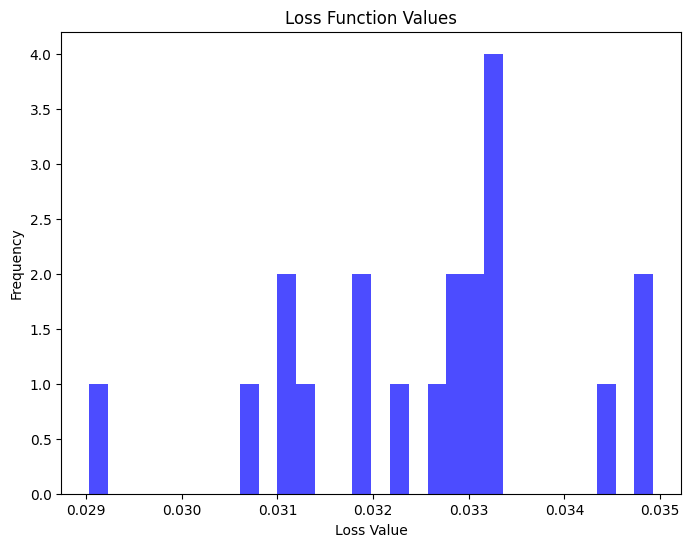

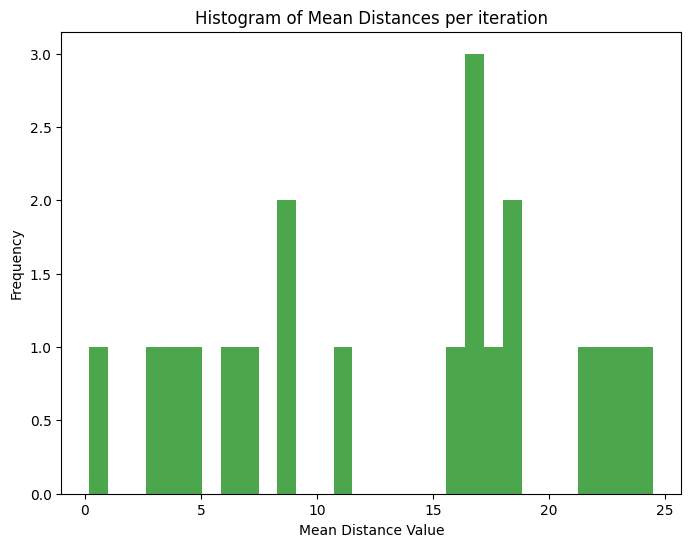

In [136]:
plot_joint_embeddings_3d(X, Y,
                         labels_X=labels,  
                            labels_Y=labels,
                            f_net=bf_net,
                            g_net=bg_net,
                            title="Simple Graph Joint Embedding",
                            point_size=4)

# Histogram of losses:
plt.figure(figsize=(8, 6))
plt.hist(loss_function_val, bins=30, color='blue', alpha=0.7)
plt.title('Loss Function Values')
plt.xlabel('Loss Value')
plt.ylabel('Frequency')
plt.show()

# Histogram of mean distances:
plt.figure(figsize=(8, 6))
plt.hist(mean_distances_error, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Mean Distances per iteration')
plt.xlabel('Mean Distance Value')
plt.ylabel('Frequency')
plt.show()

In [137]:
loss

tensor(0.0285, grad_fn=<AddBackward0>)